In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv("auto-mpg.csv")

In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [7]:
df.shape

(398, 9)

In [8]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [11]:
df['horsepower'] == '?'

0      False
1      False
2      False
3      False
4      False
       ...  
393    False
394    False
395    False
396    False
397    False
Name: horsepower, Length: 398, dtype: bool

In [12]:
(df['horsepower'] == '?').sum()

np.int64(6)

In [13]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna()

In [14]:
df['horsepower'].dtype

dtype('float64')

In [15]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [16]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [17]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

In [18]:
df['model year'].min()

np.int64(70)

In [19]:
df['model year'].max()

np.int64(82)

In [20]:
df['power_to_weight'] = df['horsepower'] / df['weight']
df['displacement_per_cylinder'] = df['displacement'] / df['cylinders']
df['weight_acceleration'] = df['weight'] * df['acceleration']

C:\Users\ivan_\AppData\Local\Temp\ipykernel_20796\3119958361.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['power_to_weight'] = df['horsepower'] / df['weight']
C:\Users\ivan_\AppData\Local\Temp\ipykernel_20796\3119958361.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['displacement_per_cylinder'] = df['displacement'] / df['cylinders']
C:\Users\ivan_\AppData\Local\Temp\ipykernel_20796\3119958361.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


In [21]:
current_year = datetime.now().year
print(current_year)

2026


In [22]:
df['model_year'] = df['model year'].apply(lambda x: 1900 + x if x >= 70 else 2000 + x)

C:\Users\ivan_\AppData\Local\Temp\ipykernel_20796\2638511694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['model_year'] = df['model year'].apply(lambda x: 1900 + x if x >= 70 else 2000 + x)


In [23]:
print(df[['model year', 'model_year']].head())


   model year  model_year
0          70        1970
1          70        1970
2          70        1970
3          70        1970
4          70        1970


In [24]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,power_to_weight,displacement_per_cylinder,weight_acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,0.037100,38.375,42048.0,1970
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,0.044679,43.750,42469.5,1970
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,0.043655,39.750,37796.0,1970
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,0.043694,38.000,41196.0,1970
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,0.040591,37.750,36214.5,1970
...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl,0.030824,35.000,43524.0,1982
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup,0.024413,24.250,52398.0,1982
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage,0.036601,33.750,26622.0,1982
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger,0.030095,30.000,48825.0,1982


In [25]:
df['car_age'] = current_year - df['model_year']

C:\Users\ivan_\AppData\Local\Temp\ipykernel_20796\3252366476.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['car_age'] = current_year - df['model_year']


In [26]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,power_to_weight,displacement_per_cylinder,weight_acceleration,model_year,car_age
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,0.037100,38.375,42048.0,1970,56
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,0.044679,43.750,42469.5,1970,56
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,0.043655,39.750,37796.0,1970,56
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,0.043694,38.000,41196.0,1970,56
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,0.040591,37.750,36214.5,1970,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl,0.030824,35.000,43524.0,1982,44
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup,0.024413,24.250,52398.0,1982,44
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage,0.036601,33.750,26622.0,1982,44
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger,0.030095,30.000,48825.0,1982,44


In [27]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,power_to_weight,displacement_per_cylinder,weight_acceleration,model_year,car_age
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531,0.034833,33.424639,45301.284694,1975.979592,50.020408
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518,0.005935,8.706997,12079.894356,3.683737,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,0.020557,17.000000,22265.000000,1970.000000,44.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,0.030820,25.062500,35645.000000,1973.000000,47.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,0.034285,33.354167,43214.000000,1976.000000,50.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000,0.038082,39.000000,53445.000000,1979.000000,53.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,0.072910,56.875000,87542.000000,1982.000000,56.000000


In [28]:
df.dtypes

mpg                          float64
cylinders                      int64
displacement                 float64
horsepower                   float64
weight                         int64
acceleration                 float64
model year                     int64
origin                         int64
car name                      object
power_to_weight              float64
displacement_per_cylinder    float64
weight_acceleration          float64
model_year                     int64
car_age                        int64
dtype: object

In [29]:
df.isnull().sum()

mpg                          0
cylinders                    0
displacement                 0
horsepower                   0
weight                       0
acceleration                 0
model year                   0
origin                       0
car name                     0
power_to_weight              0
displacement_per_cylinder    0
weight_acceleration          0
model_year                   0
car_age                      0
dtype: int64

In [30]:
df['origin'].value_counts()

origin
1    245
3     79
2     68
Name: count, dtype: int64

In [31]:
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                'acceleration', 'power_to_weight', 'displacement_per_cylinder', 
                'weight_acceleration', 'car_age']


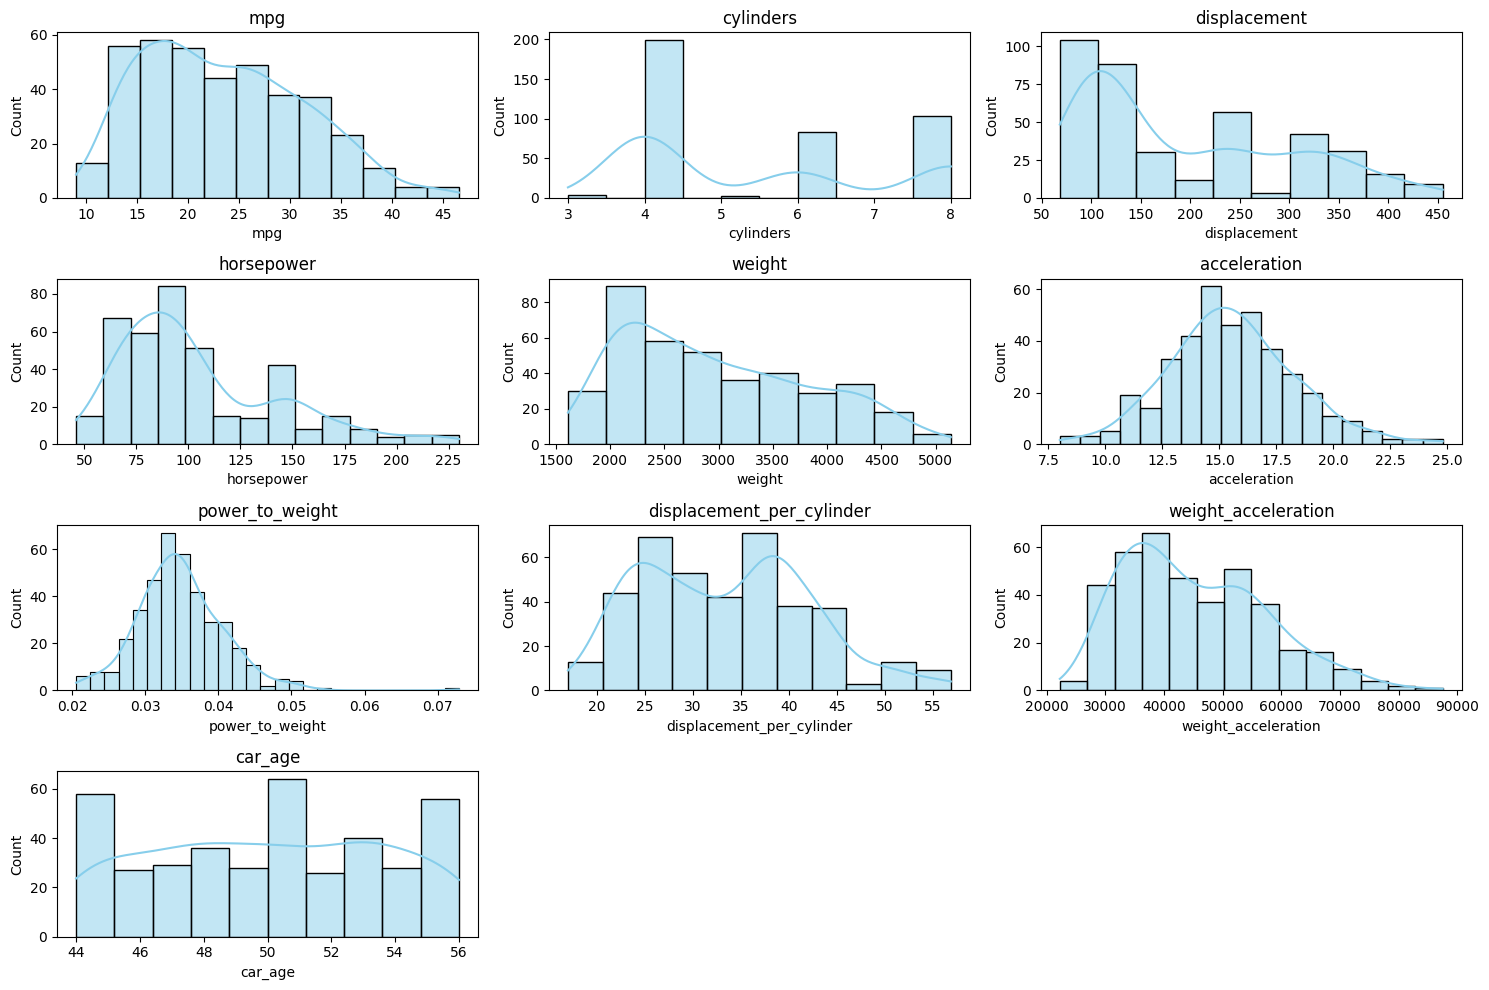

In [32]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

C:\Users\ivan_\AppData\Local\Temp\ipykernel_20796\3234191519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
C:\Users\ivan_\AppData\Local\Temp\ipykernel_20796\3234191519.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


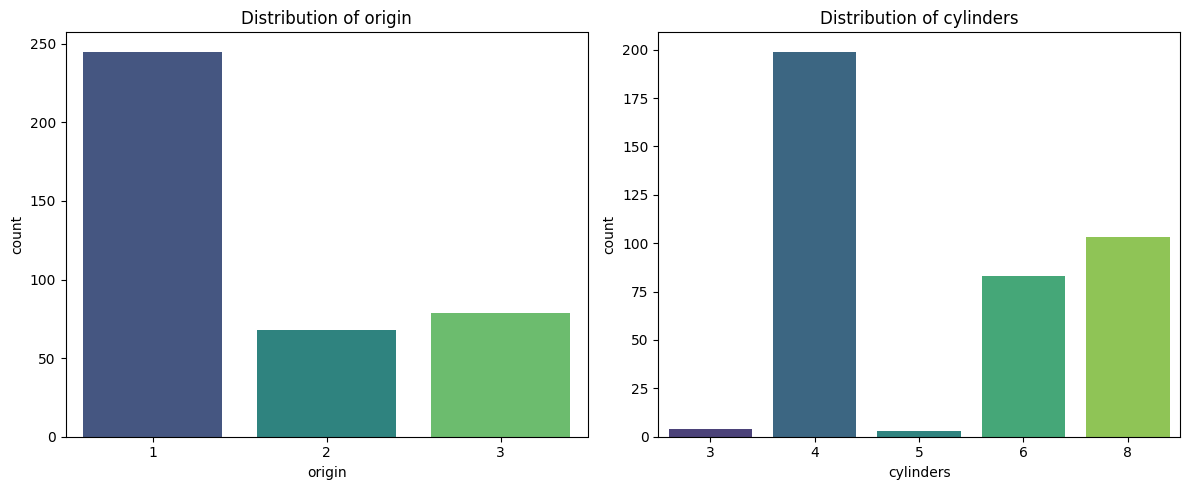

In [33]:
categorical_cols = ['origin', 'cylinders']
plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols, 1):
  plt.subplot(1, 2, i)
  sns.countplot(x=df[col], palette='viridis')
  plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

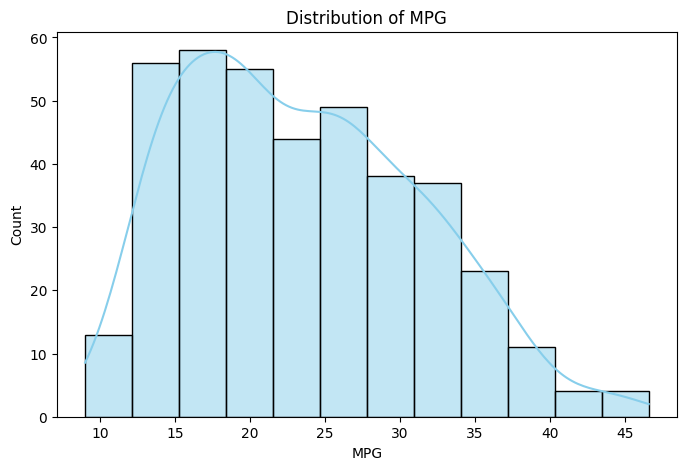

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['mpg'], kde= True, color='skyblue')
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Count")
plt.show()

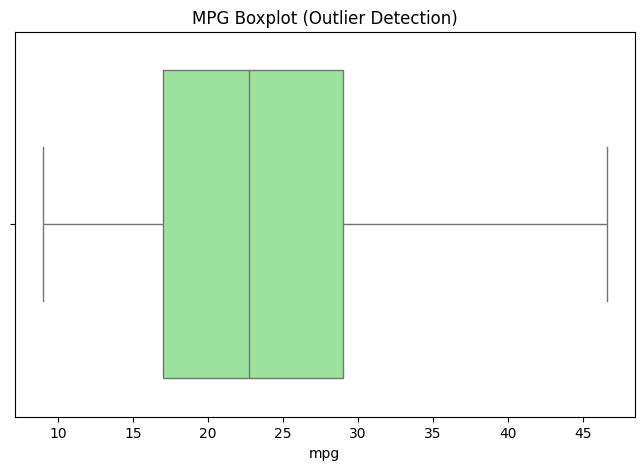

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['mpg'], color='lightgreen')
plt.title("MPG Boxplot (Outlier Detection)")
plt.show()

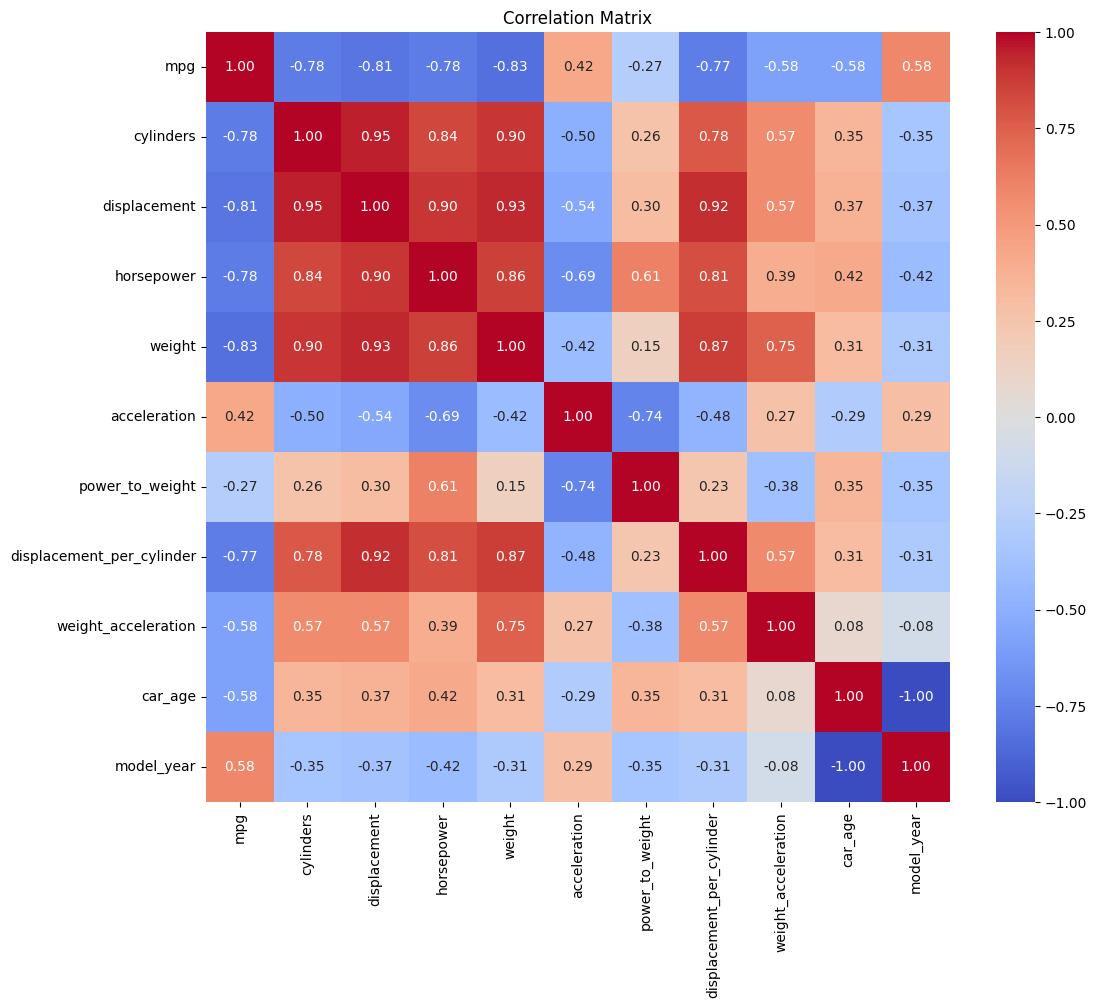

In [36]:
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols + ['model_year']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

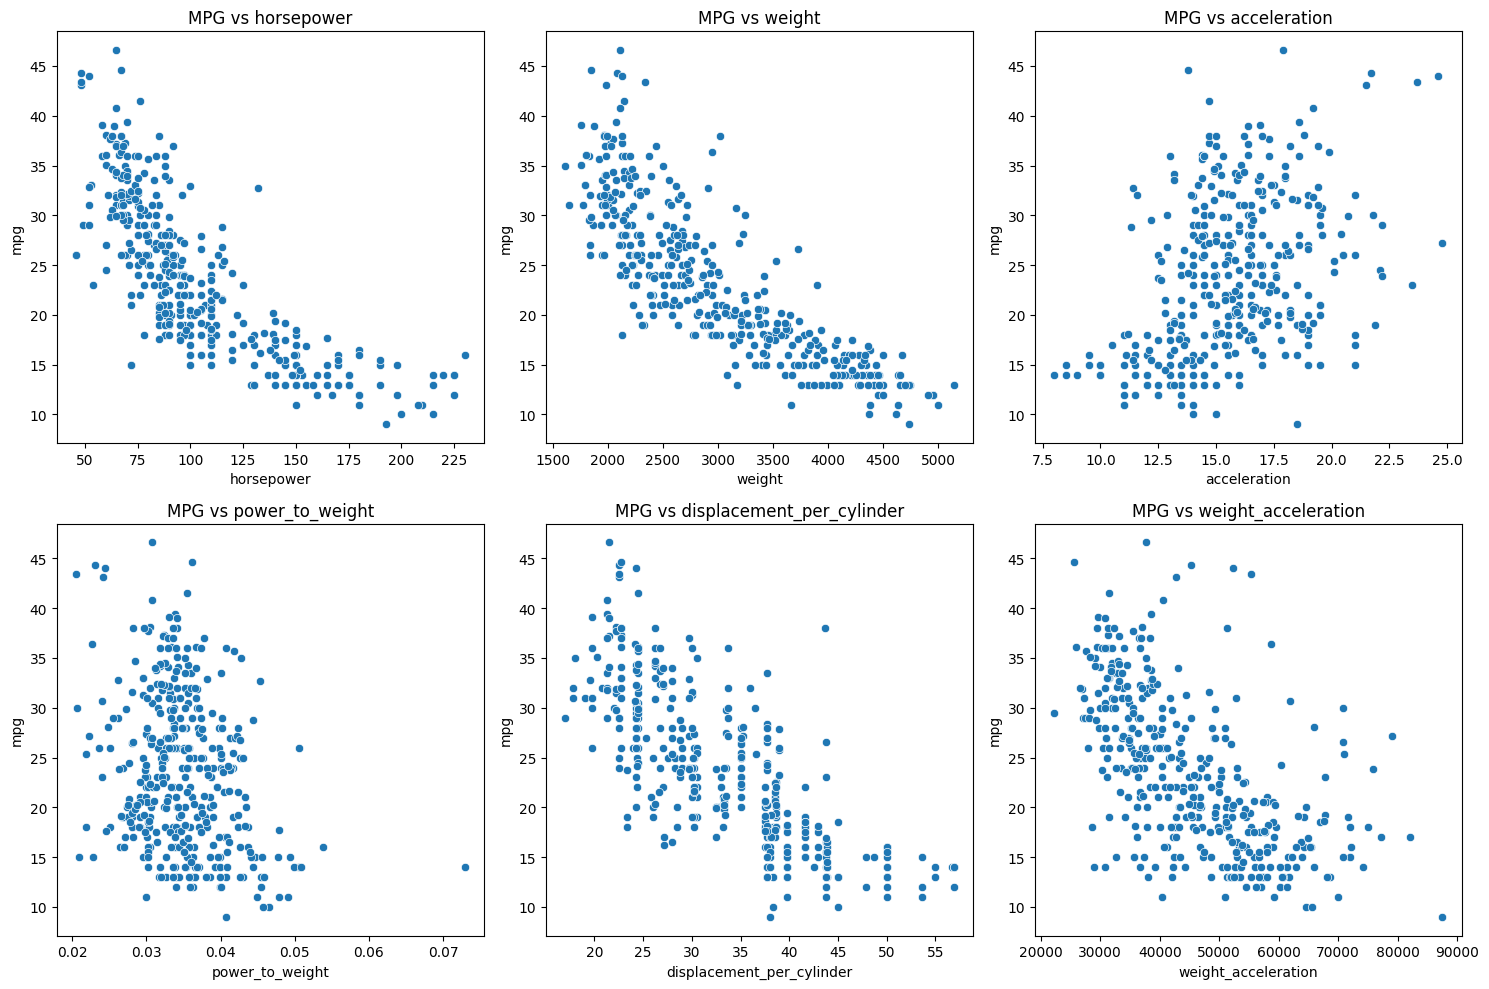

In [37]:
features = ['horsepower','weight','acceleration','power_to_weight','displacement_per_cylinder','weight_acceleration']
plt.figure(figsize=(15,10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[col], y=df['mpg'])
    plt.title(f"MPG vs {col}")
plt.tight_layout()
plt.show()

In [38]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,power_to_weight,displacement_per_cylinder,weight_acceleration,model_year,car_age
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,0.037100,38.375,42048.0,1970,56
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,0.044679,43.750,42469.5,1970,56
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,0.043655,39.750,37796.0,1970,56
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,0.043694,38.000,41196.0,1970,56
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,0.040591,37.750,36214.5,1970,56


In [39]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,power_to_weight,displacement_per_cylinder,weight_acceleration,model_year,car_age
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,0.037100,38.375,42048.0,1970,56
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,0.044679,43.750,42469.5,1970,56
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,0.043655,39.750,37796.0,1970,56
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,0.043694,38.000,41196.0,1970,56
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,0.040591,37.750,36214.5,1970,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl,0.030824,35.000,43524.0,1982,44
394,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup,0.024413,24.250,52398.0,1982,44
395,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage,0.036601,33.750,26622.0,1982,44
396,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger,0.030095,30.000,48825.0,1982,44


In [40]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 
            'acceleration', 'origin', 'power_to_weight', 
            'displacement_per_cylinder', 'weight_acceleration', 'car_age']
target = 'mpg'

X = df[features]
y = df[target]

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [43]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train_scaled, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [44]:
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R^2 Score: {r2:.2f}")


RMSE: 2.40
R^2 Score: 0.89


In [45]:
import xgboost as xgb

In [46]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 
            'acceleration', 'origin', 'power_to_weight', 
            'displacement_per_cylinder', 'weight_acceleration', 'car_age']
target = 'mpg'

X = df[features]
y = df[target]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (optional but helps sometimes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost Regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [48]:
y_pred = xgb_model.predict(X_test_scaled)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost R^2: {r2:.2f}")

XGBoost RMSE: 2.24
XGBoost R^2: 0.90


In [49]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)


                     feature  importance
1               displacement    0.392789
2                 horsepower    0.161949
0                  cylinders    0.147365
3                     weight    0.125400
9                    car_age    0.099914
7  displacement_per_cylinder    0.021926
8        weight_acceleration    0.018983
6            power_to_weight    0.016301
4               acceleration    0.011688
5                     origin    0.003685


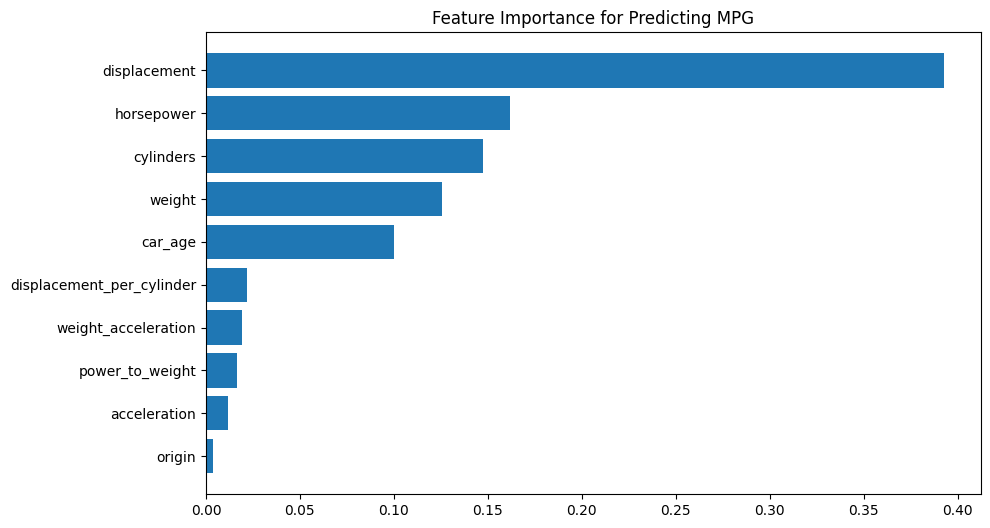

In [50]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance for Predicting MPG")
plt.show()

In [51]:
predictions_df = pd.DataFrame({
    'Actual_MPG': y_test,
    'Predicted_MPG': y_pred
}).reset_index(drop=True)

print(predictions_df.head(10)) 

   Actual_MPG  Predicted_MPG
0        26.0      26.857130
1        21.6      21.933781
2        36.1      34.972157
3        26.0      28.985426
4        27.0      26.472832
5        28.0      26.706375
6        13.0      12.571625
7        26.0      28.064814
8        19.0      18.841515
9        29.0      28.703693


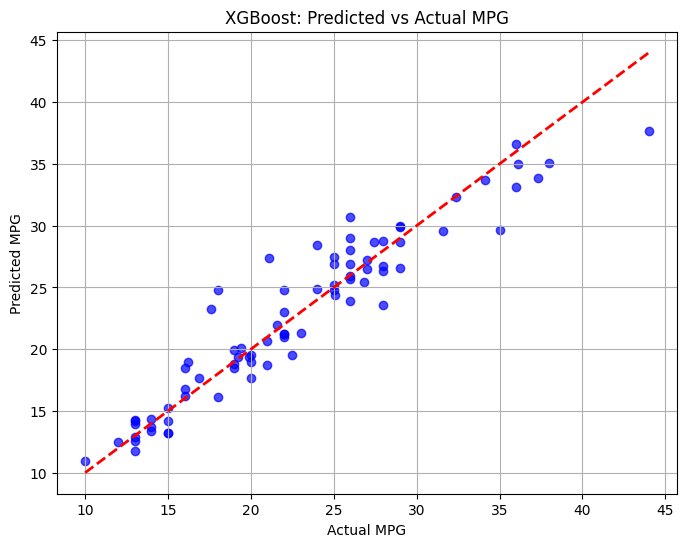

In [52]:
plt.figure(figsize=(8,6))
plt.scatter(predictions_df['Actual_MPG'], predictions_df['Predicted_MPG'], alpha=0.7, color='blue')
plt.plot([predictions_df['Actual_MPG'].min(), predictions_df['Actual_MPG'].max()],
         [predictions_df['Actual_MPG'].min(), predictions_df['Actual_MPG'].max()],
         'r--', lw=2)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("XGBoost: Predicted vs Actual MPG")
plt.grid(True)
plt.show()